## Section 3.2 Multioutput ANN models

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model, Sequential, save_model
from tensorflow.keras.layers import Dense, Input, BatchNormalization
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Input, Dropout

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
X_train = pd.read_csv('Data/Splitting/Train/Generic/X/X_train.csv')
y_train_FSO = pd.read_csv('Data/Splitting/Train/Generic/Y/y_train_FSO.csv')
y_train_RF = pd.read_csv('Data/Splitting/Train/Generic/Y/y_train_RF.csv')

X_val = pd.read_csv('Data/Splitting/Validation/Generic/X/X_val.csv')
y_val_FSO = pd.read_csv('Data/Splitting/Validation/Generic/Y/y_val_FSO.csv')
y_val_RF = pd.read_csv('Data/Splitting/Validation/Generic/Y/y_val_RF.csv')

In [3]:
# One-hot encoding categorical features
categorical_columns = ['Hour', 'Freq', 'SC']
encoder = OneHotEncoder(sparse_output=False)
encoded_cats = encoder.fit_transform(X_train[categorical_columns])

# Drop original categorical columns and add encoded columns
X_train = X_train.drop(categorical_columns, axis=1)
X_train = np.concatenate([X_train, encoded_cats], axis=1)

# Apply the same encoding to validation data
encoded_cats_val = encoder.transform(X_val[categorical_columns])
X_val = X_val.drop(categorical_columns, axis=1)
X_val = np.concatenate([X_val, encoded_cats_val], axis=1)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Combine FSO and RF target variables into a single DataFrame for training and validation
y_train = pd.concat([
    y_train_FSO.squeeze().rename("FSO_Att"),
    y_train_RF.squeeze().rename("RFL_Att")
], axis=1)

y_val = pd.concat([
    y_val_FSO.squeeze().rename("FSO_Att"),
    y_val_RF.squeeze().rename("RFL_Att")
], axis=1)


In [4]:
def rmse_fso(y_true, y_pred):
    """
    Calculate RMSE for the FSO channel (output index 0).
    """
    return tf.sqrt(tf.reduce_mean(tf.square(y_true[:, 0] - y_pred[:, 0])))

def rmse_rf(y_true, y_pred):
    """
    Calculate RMSE for the RF channel (output index 1).
    """
    return tf.sqrt(tf.reduce_mean(tf.square(y_true[:, 1] - y_pred[:, 1])))

def r2_fso(y_true, y_pred):
    """
    Calculate R² score for the FSO channel (output index 0).
    """
    ss_res = tf.reduce_sum(tf.square(y_true[:, 0] - y_pred[:, 0]))
    ss_tot = tf.reduce_sum(tf.square(y_true[:, 0] - tf.reduce_mean(y_true[:, 0])))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())

def r2_rf(y_true, y_pred):
    """
    Calculate R² score for the RF channel (output index 1).
    """
    ss_res = tf.reduce_sum(tf.square(y_true[:, 1] - y_pred[:, 1]))
    ss_tot = tf.reduce_sum(tf.square(y_true[:, 1] - tf.reduce_mean(y_true[:, 1])))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())

In [5]:
def build_multioutput_ann_model(X_train, y_train, X_val, y_val, units,
                                num_layers, learning_rate=0.001, activation='relu', epochs=50, batch_size=32):
    """
    Build, train, and evaluate a multi-output ANN model for FSO and RF attenuation.
    
    """
    # Initialize the model
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    # Add hidden layers
    for i in range(num_layers):
        model.add(Dense(units[i], activation=activation))
        model.add(BatchNormalization())

    # Add output layer for two outputs: FSO and RF attenuation
    model.add(Dense(2, activation='linear'))

    # Compile the model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer, 
        loss='mse', 
        metrics=[rmse_fso, rmse_rf, r2_fso, r2_rf]
    )

    # Train the model
    history = model.fit(
        X_train, y_train, 
        epochs=epochs, 
        batch_size=batch_size, 
        validation_data=(X_val, y_val), 
        verbose=0
    )

    # Extract final metrics
    final_epoch = epochs - 1
    final_metrics = {
        "Training Loss": history.history['loss'][final_epoch],
        "Validation Loss": history.history['val_loss'][final_epoch],
        "Training RMSE FSO": history.history['rmse_fso'][final_epoch],
        "Validation RMSE FSO": history.history['val_rmse_fso'][final_epoch],
        "Training RMSE RF": history.history['rmse_rf'][final_epoch],
        "Validation RMSE RF": history.history['val_rmse_rf'][final_epoch],
        "Training R² FSO": history.history['r2_fso'][final_epoch],
        "Validation R² FSO": history.history['val_r2_fso'][final_epoch],
        "Training R² RF": history.history['r2_rf'][final_epoch],
        "Validation R² RF": history.history['val_r2_rf'][final_epoch]
    }

    return model, final_metrics, history.history

In [6]:
def ann_gridsearch(X_train, y_train, X_val, y_val, 
                   epochs=50,
                   layer_units=[32, 64], 
                   num_layers_options=[2, 3], 
                   activation_options=['tanh', 'sigmoid'], 
                   learning_rate_options=[0.01]):
    """
    Perform a grid search to tune hyperparameters of an ANN.

    Parameters:
    - X_train, y_train: Training dataset
    - X_val, y_val: Validation dataset
    - epochs: Number of epochs for training (default: 50)
    - layer_units: List of units per layer (e.g., [32, 64])
    - num_layers_options: List of hidden layer options (e.g., [2, 3])
    - activation_options: List of activation functions (e.g., ['tanh', 'sigmoid'])
    - learning_rate_options: List of learning rates (e.g., [0.01])

    Returns:
    - results_df: DataFrame containing performance metrics for each configuration
    - models: List of trained models
    - histories: List of training histories for visualization
    """
    
    results = []
    histories = []  # To store training histories for all models
    models = []     # To store trained models for saving later

    for num_layers in num_layers_options:
        # Generate all unit combinations for the given number of layers
        units_options = list(product(layer_units, repeat=num_layers))
        
        for units in units_options:
            for activation in activation_options:
                for learning_rate in learning_rate_options:
                    print(f"\nRunning model with Units: {units}, Layers: {num_layers}, "
                          f"Activation: {activation}, LR: {learning_rate}")
                        
                    # Build and train the model
                    model, final_metrics, history = build_multioutput_ann_model(
                        X_train, y_train, X_val, y_val,
                        units=units, num_layers=num_layers,
                        learning_rate=learning_rate, activation=activation, epochs=epochs
                    )
                        
                    # Store the trained model
                    models.append(model)
                        
                    # Store the training history
                    histories.append({
                        'history': history,
                        'Model Name': f"ANN-{units}-{activation}-{learning_rate}"
                    })
                        
                    # Store the results
                    result = {
                        'Model Name': f"ANN-{units}-{activation}-{learning_rate}",
                        'Units': units,
                        'Layers': num_layers,
                        'Activation': activation,
                        'Learning Rate': learning_rate,
                        'Training Loss': final_metrics["Training Loss"],
                        'Validation Loss': final_metrics["Validation Loss"],
                        'Training RMSE FSO': final_metrics["Training RMSE FSO"],
                        'Validation RMSE FSO': final_metrics["Validation RMSE FSO"],
                        'Training RMSE RF': final_metrics["Training RMSE RF"],
                        'Validation RMSE RF': final_metrics["Validation RMSE RF"],
                        'Training R² FSO': final_metrics["Training R² FSO"],
                        'Validation R² FSO': final_metrics["Validation R² FSO"],
                        'Training R² RF': final_metrics["Training R² RF"],
                        'Validation R² RF': final_metrics["Validation R² RF"]
                    }
                    results.append(result)

    # Convert results to a DataFrame for easy display
    results_df = pd.DataFrame(results)
     
    print("\nSummary of All Model Configurations:")
    try:
        display(results_df)  # For Jupyter Notebooks
    except NameError:
        print(results_df)  # For other environments
    
    return results_df, models, histories

In [7]:
def plot_best_models(results_df, histories, top_num=3):
    """
    Plot the training and validation metrics for the top models.

    Parameters:
    - results_df: DataFrame containing model configurations and their performance metrics.
    - histories: List of dictionaries with training history and model names.
    - top_num: Number of top models to plot based on combined Validation R² and Validation RMSE.

    Returns:
    - None. Displays the plots for the top models.
    """
    
    # Combine Validation RMSE and R² for FSO and RF
    results_df['Combined Validation RMSE'] = (results_df['Validation RMSE FSO'] + results_df['Validation RMSE RF']) / 2
    results_df['Combined Validation R²'] = (results_df['Validation R² FSO'] + results_df['Validation R² RF']) / 2

    # Sort by highest Combined Validation R² and lowest Combined Validation RMSE
    top_models = results_df.sort_values(by=['Combined Validation R²', 'Combined Validation RMSE'], ascending=[False, True]).head(top_num)
    
    print(f"\nTop {top_num} Model Configurations with Highest Combined Validation R² and Lowest Combined Validation RMSE:")
    try:
        display(top_models)  # For Jupyter Notebooks
    except NameError:
        print(top_models)  # For non-Jupyter environments
    
    # Create subplots for metric curves
    num_top_models = len(top_models)
    fig, axes = plt.subplots(num_top_models, 1, figsize=(12, num_top_models * 4))
    
    # Handle single subplot case
    if num_top_models == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, top_models.iterrows()):
        # Find the matching history for the current top model
        matching_history = next(
            (h['history'] for h in histories if h['Model Name'] == row['Model Name']),
            None
        )
        
        if matching_history is None:
            print(f"No matching history found for model: {row['Model Name']}")
            continue
        
        # Plot metrics
        ax.plot(matching_history['loss'], label='Training Loss', linestyle='--')
        ax.plot(matching_history['val_loss'], label='Validation Loss', linestyle='-')
        ax.plot(matching_history['rmse_fso'], label='Training RMSE FSO', linestyle='--')
        ax.plot(matching_history['val_rmse_fso'], label='Validation RMSE FSO', linestyle='-')
        ax.plot(matching_history['rmse_rf'], label='Training RMSE RF', linestyle='--')
        ax.plot(matching_history['val_rmse_rf'], label='Validation RMSE RF', linestyle='-')
        ax.plot(matching_history['r2_fso'], label='Training R² FSO', linestyle='--')
        ax.plot(matching_history['val_r2_fso'], label='Validation R² FSO', linestyle='-')
        ax.plot(matching_history['r2_rf'], label='Training R² RF', linestyle='--')
        ax.plot(matching_history['val_r2_rf'], label='Validation R² RF', linestyle='-')
        ax.set_title(f"Metrics for Top Model: {row['Model Name']}", fontsize=14)
        ax.set_xlabel('Epochs', fontsize=12)
        ax.set_ylabel('Metrics', fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()

In [8]:
def save_best_model(results_df, models, histories, nntype):
    """
    Save the best model based on Validation R² and RMSE.

    Parameters:
    - results_df: DataFrame containing model configurations and their performance metrics.
    - models: List of trained models corresponding to the results_df rows.
    - histories: List of training histories corresponding to the models.
    - nntype: A string indicating the type of neural network (e.g., 'ANN', 'CNN').

    Returns:
    - model_save_path: The file path where the best model was saved.
    """
    
    # Combine Validation RMSE and R² for FSO and RF
    results_df['Combined Validation RMSE'] = (results_df['Validation RMSE FSO'] + results_df['Validation RMSE RF']) / 2
    results_df['Combined Validation R²'] = (results_df['Validation R² FSO'] + results_df['Validation R² RF']) / 2

    # Sort by highest Validation R² and lowest Validation RMSE
    top_model_index = results_df.sort_values(
        by=['Combined Validation R²', 'Combined Validation RMSE'], ascending=[False, True]
    ).index[0]  # Get the index of the best model
    
    # Retrieve the best model and its details
    best_model = models[top_model_index]
    best_result = results_df.iloc[top_model_index]
    best_history = histories[top_model_index]['history']
    
    # Ensure the directory for saved models exists
    os.makedirs("saved_models", exist_ok=True)
    
    # Save the best model
    model_save_path = f"saved_models/multioutput_best_{nntype}_model.h5"
    save_model(best_model, model_save_path)
    print(f"\nBest {nntype} model saved to: {model_save_path}")
    
    # Print details of the best model
    print(f"\nBest {nntype} Model Details:")
    print(best_result)
    
    return model_save_path


In [9]:
# Define hyperparameters for the ANN grid search
layer_units = [32, 64, 128, 256]
num_layers_options = [2, 3]
activation_options = ['relu', 'tanh', 'sigmoid']
learning_rate_options = [0.01, 0.001]

In [10]:
# Run grid search for ANN model targeting FSO attenuation
ann_multi_results, ann_multi_models, ann_multi_histories = ann_gridsearch(
    X_train=X_train, 
    y_train=y_train, 
    X_val=X_val, 
    y_val=y_val, 
    epochs=50, 
    layer_units=layer_units, 
    num_layers_options=num_layers_options,
    activation_options=activation_options, 
    learning_rate_options=learning_rate_options
)


Running model with Units: (32, 32), Layers: 2, Activation: relu, LR: 0.01

Running model with Units: (32, 32), Layers: 2, Activation: relu, LR: 0.001

Running model with Units: (32, 32), Layers: 2, Activation: tanh, LR: 0.01

Running model with Units: (32, 32), Layers: 2, Activation: tanh, LR: 0.001

Running model with Units: (32, 32), Layers: 2, Activation: sigmoid, LR: 0.01

Running model with Units: (32, 32), Layers: 2, Activation: sigmoid, LR: 0.001

Running model with Units: (32, 64), Layers: 2, Activation: relu, LR: 0.01

Running model with Units: (32, 64), Layers: 2, Activation: relu, LR: 0.001

Running model with Units: (32, 64), Layers: 2, Activation: tanh, LR: 0.01

Running model with Units: (32, 64), Layers: 2, Activation: tanh, LR: 0.001

Running model with Units: (32, 64), Layers: 2, Activation: sigmoid, LR: 0.01

Running model with Units: (32, 64), Layers: 2, Activation: sigmoid, LR: 0.001

Running model with Units: (32, 128), Layers: 2, Activation: relu, LR: 0.01

Runni

,Model Name,Units,Layers,Activation,Learning Rate,Training Loss,Validation Loss,Training RMSE FSO,Validation RMSE FSO,Training RMSE RF,Validation RMSE RF,Training R² FSO,Validation R² FSO,Training R² RF,Validation R² RF
0,"ANN-(32, 32)-relu-0.01","(32, 32)",2,relu,0.010,1.864218,1.329730,1.545984,1.355366,0.992920,0.733872,0.811213,0.849732,0.890878,0.941080
1,"ANN-(32, 32)-relu-0.001","(32, 32)",2,relu,0.001,1.812496,1.313848,1.531144,1.311427,0.976649,0.787130,0.815645,0.863708,0.898051,0.934719
2,"ANN-(32, 32)-tanh-0.01","(32, 32)",2,tanh,0.010,2.261233,2.184803,1.649326,1.615770,1.180230,1.096799,0.787135,0.778281,0.852378,0.870146
3,"ANN-(32, 32)-tanh-0.001","(32, 32)",2,tanh,0.001,1.774549,1.272564,1.500805,1.298677,0.981814,0.764689,0.822549,0.863438,0.895870,0.939362
4,"ANN-(32, 32)-sigmoid-0.01","(32, 32)",2,sigmoid,0.010,1.921225,1.872884,1.545278,1.547721,1.053252,0.959306,0.813635,0.806860,0.880041,0.908244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,"ANN-(256, 256, 256)-relu-0.001","(256, 256, 256)",3,relu,0.001,1.032783,0.733407,1.111463,0.968460,0.764902,0.562524,0.899346,0.922970,0.932446,0.965957
476,"ANN-(256, 256, 256)-tanh-0.01","(256, 256, 256)",3,tanh,0.010,5.551001,6.682501,2.620719,2.772840,1.896112,2.147747,0.497961,0.392430,0.634402,0.526611
477,"ANN-(256, 256, 256)-tanh-0.001","(256, 256, 256)",3,tanh,0.001,1.027790,0.745942,1.098913,0.971365,0.783774,0.613653,0.899389,0.923627,0.930239,0.958381
478,"ANN-(256, 256, 256)-sigmoid-0.01","(256, 256, 256)",3,sigmoid,0.010,3.683100,3.250064,2.144650,1.946803,1.494521,1.433796,0.653679,0.701517,0.766768,0.773918



Top 5 Model Configurations with Highest Combined Validation R² and Lowest Combined Validation RMSE:


,Model Name,Units,Layers,Activation,Learning Rate,Training Loss,Validation Loss,Training RMSE FSO,Validation RMSE FSO,Training RMSE RF,Validation RMSE RF,Training R² FSO,Validation R² FSO,Training R² RF,Validation R² RF,Combined Validation RMSE,Combined Validation R²
463,"ANN-(256, 256, 64)-relu-0.001","(256, 256, 64)",3,relu,0.001,1.084041,0.697662,1.156461,0.963248,0.760845,0.545168,0.889356,0.924982,0.934439,0.968119,0.754208,0.946550
473,"ANN-(256, 256, 128)-sigmoid-0.001","(256, 256, 128)",3,sigmoid,0.001,1.076492,0.689801,1.134803,0.934742,0.784442,0.575242,0.891265,0.928210,0.930593,0.963493,0.754992,0.945852
359,"ANN-(128, 128, 256)-sigmoid-0.001","(128, 128, 256)",3,sigmoid,0.001,1.141575,0.701093,1.177079,0.966202,0.797555,0.552951,0.885931,0.924524,0.926970,0.966270,0.759577,0.945397
471,"ANN-(256, 256, 128)-tanh-0.001","(256, 256, 128)",3,tanh,0.001,1.053005,0.700193,1.114704,0.955420,0.787064,0.562193,0.896914,0.925424,0.930261,0.965133,0.758806,0.945279
475,"ANN-(256, 256, 256)-relu-0.001","(256, 256, 256)",3,relu,0.001,1.032783,0.733407,1.111463,0.968460,0.764902,0.562524,0.899346,0.922970,0.932446,0.965957,0.765492,0.944463


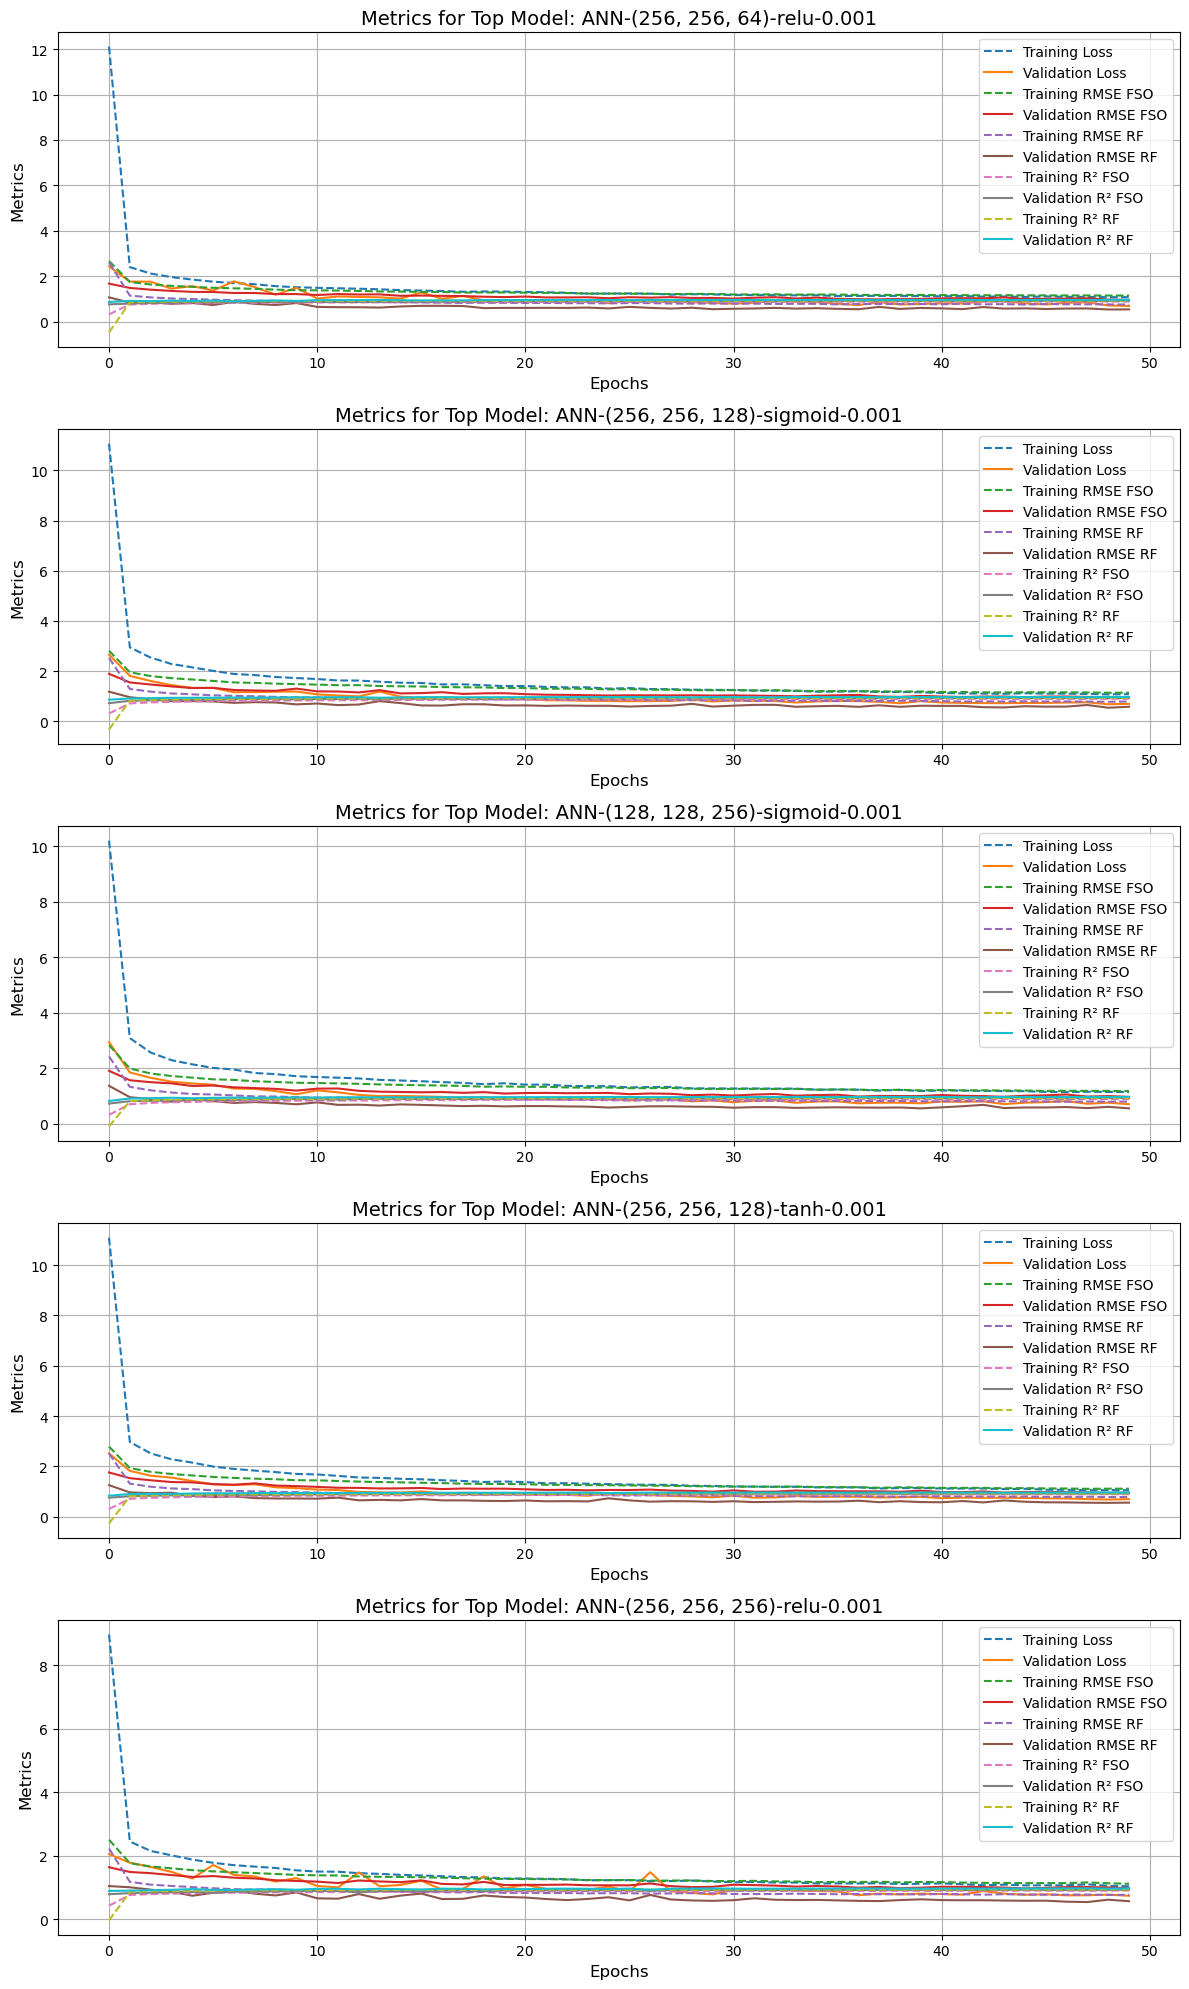

In [11]:
# Plot metrics for the top 5 models
plot_best_models(ann_multi_results, ann_multi_histories, top_num=5)

In [12]:
# Save the best ANN model for FSO attenuation
save_best_model(ann_multi_results, ann_multi_models, ann_multi_histories, "ANN")


Best ANN model saved to: saved_models/multioutput_best_ANN_model.h5

Best ANN Model Details:
Model Name                  ANN-(256, 256, 64)-relu-0.001
Units                                      (256, 256, 64)
Layers                                                  3
Activation                                           relu
Learning Rate                                       0.001
Training Loss                                    1.084041
Validation Loss                                  0.697662
Training RMSE FSO                                1.156461
Validation RMSE FSO                              0.963248
Training RMSE RF                                 0.760845
Validation RMSE RF                               0.545168
Training R² FSO                                  0.889356
Validation R² FSO                                0.924982
Training R² RF                                   0.934439
Validation R² RF                                 0.968119
Combined Validation RMSE            

'saved_models/multioutput_best_ANN_model.h5'

In [13]:
def load_and_predict(model_path, X_val, output_path, df_prediction):
    """
    Load a trained model, make predictions, and save the updated results.

    Parameters:
    - model_path (str): Path to the saved model file.
    - X_val (DataFrame): Validation feature dataset.
    - output_path (str): Path to save the updated results.
    - df_method1 (DataFrame): Original DataFrame to update with predictions.
    - label (str): Label for the predictions (default is "FSO").

    Returns:
    - None
    """
    # Load the model
    model = load_model(model_path,compile=False)
    print(f"Model loaded from {model_path}")

    # Make predictions
    predicted_values = model.predict(X_val).squeeze()
    print(f"Predictions completed")

    # Assign each column to its respective label
    df_prediction['Predicted_FSO'] = predicted_values[:, 0]  # First column: FSO
    df_prediction['Predicted_RF'] = predicted_values[:, 1]   # Second column: RF

    # Save the updated DataFrame
    df_prediction.to_csv(output_path, index=False)
    print(f"Updated results saved to: {output_path}")

In [14]:
# === Configuration ===
model_path = 'saved_models/multioutput_best_ANN_model.h5'
df_prediction = pd.read_csv("Data/Splitting/Validation/Generic/X/X_val.csv")
output_path = 'Data/Predicted/Validation/val_ann_combined_prediction.csv'  # Final output

load_and_predict(
    model_path=model_path,
    X_val=X_val,
    output_path=output_path,
    df_prediction=df_prediction
)

Model loaded from saved_models/multioutput_best_ANN_model.h5
457/457 ━━━━━━━━━━━━━━━━━━━━ 0s 428us/step
Predictions completed
Updated results saved to: Data/Predicted/Validation/val_ann_combined_prediction.csv
